# 04 - GITT and PITT

GITT and PITT are intermittent titration methods. They are useful because
they separate an imposed perturbation from the relaxation that follows.

- GITT: current pulse, then rest.
- PITT: voltage step, then current decay/rest.

Docs:

- Experiment API: https://docs.pybamm.org/en/stable/source/api/experiment/experiment.html
- Experiment step functions: https://docs.pybamm.org/en/stable/source/api/experiment/experiment_steps.html

In [1]:
import os

os.environ.setdefault("PYBAMM_DISABLE_TELEMETRY", "true")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pybamm

print("PyBaMM version:", pybamm.__version__)

PyBaMM version: 26.6.2.0


## Important formulas

GITT records voltage changes during a small current pulse:

$$
\Delta E_{\tau} = E_{before} - E_{end\ pulse}
$$

and after relaxation:

$$
\Delta E_s = E_{before} - E_{after\ rest}
$$

Classical diffusion estimates use a proportionality like:

$$
D \propto \frac{1}{\tau}\left(\frac{\Delta E_s}{\Delta E_{\tau}}\right)^2
$$

That formula requires geometry and small-perturbation assumptions. Here we
focus on the voltage/current information students can see directly.

PITT applies a voltage step and observes the transient current:

$$
V(t) = V_{step}, \qquad I(t) \rightarrow 0
$$

## GITT: current pulses and rests

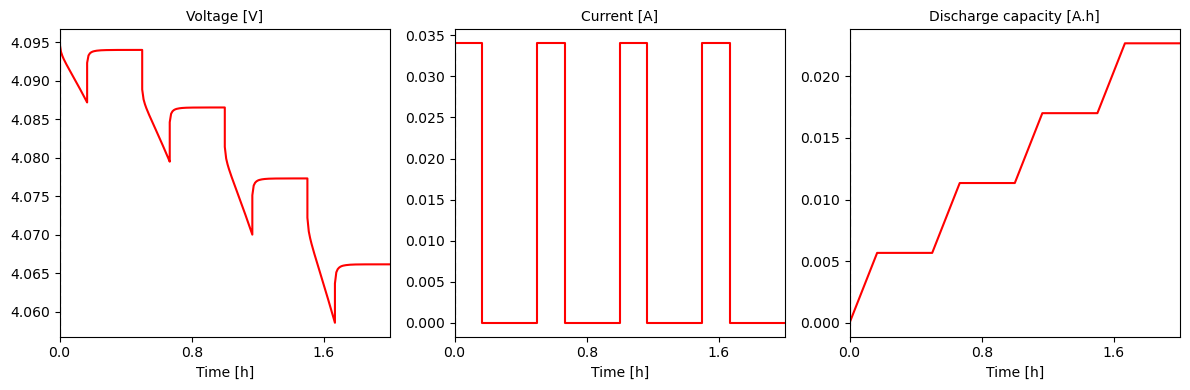

In [2]:
n_pulses = 4
pulse_minutes = 10
rest_minutes = 20

gitt_cycle = (
    f"Discharge at C/20 for {pulse_minutes} minutes",
    f"Rest for {rest_minutes} minutes",
)
gitt_experiment = pybamm.Experiment([gitt_cycle] * n_pulses, period="30 seconds")

gitt_model = pybamm.lithium_ion.DFN()
gitt_sim = pybamm.Simulation(
    gitt_model,
    parameter_values=gitt_model.default_parameter_values,
    experiment=gitt_experiment,
    output_variables=["Voltage [V]", "Current [A]", "Discharge capacity [A.h]"],
)
gitt_solution = gitt_sim.solve(initial_soc=1)

pybamm.QuickPlot(
    gitt_solution,
    ["Voltage [V]", "Current [A]", "Discharge capacity [A.h]"],
).plot(0)

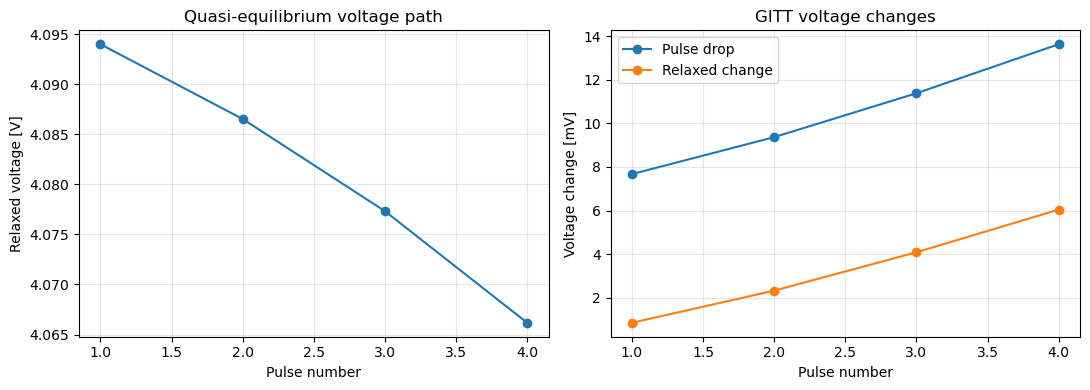

In [3]:
gitt_rows = []

for index, cycle in enumerate(gitt_solution.cycles, start=1):
    pulse = cycle.steps[0]
    rest = cycle.steps[1]

    v_before = pulse["Voltage [V]"].entries[0]
    v_end_pulse = pulse["Voltage [V]"].entries[-1]
    v_after_rest = rest["Voltage [V]"].entries[-1]
    q_after_rest = rest["Discharge capacity [A.h]"].entries[-1]

    gitt_rows.append(
        {
            "pulse": index,
            "capacity_ah": q_after_rest,
            "delta_e_tau": v_before - v_end_pulse,
            "delta_e_s": v_before - v_after_rest,
            "relaxed_voltage": v_after_rest,
        }
    )

pulses = np.array([row["pulse"] for row in gitt_rows])
relaxed_voltage = np.array([row["relaxed_voltage"] for row in gitt_rows])
delta_e_tau = np.array([row["delta_e_tau"] for row in gitt_rows])
delta_e_s = np.array([row["delta_e_s"] for row in gitt_rows])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(pulses, relaxed_voltage, "o-")
axes[0].set_xlabel("Pulse number")
axes[0].set_ylabel("Relaxed voltage [V]")
axes[0].set_title("Quasi-equilibrium voltage path")
axes[0].grid(True, alpha=0.3)

axes[1].plot(pulses, 1000 * delta_e_tau, "o-", label="Pulse drop")
axes[1].plot(pulses, 1000 * delta_e_s, "o-", label="Relaxed change")
axes[1].set_xlabel("Pulse number")
axes[1].set_ylabel("Voltage change [mV]")
axes[1].set_title("GITT voltage changes")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

## PITT: voltage steps and current transients

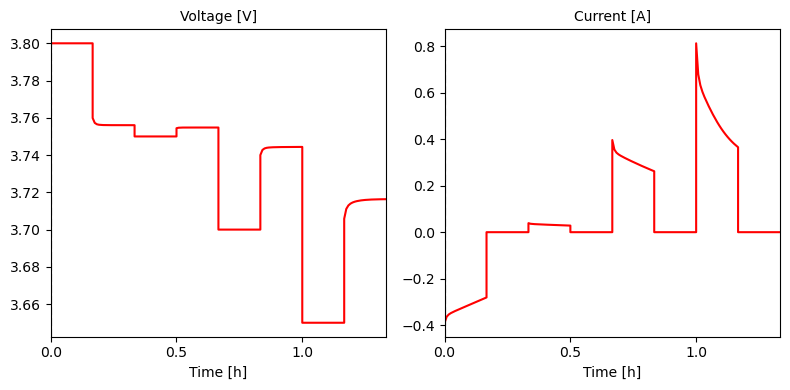

In [4]:
voltage_steps = [3.80, 3.75, 3.70, 3.65]
pitt_cycles = [
    (f"Hold at {voltage:.3f} V for 10 minutes", "Rest for 10 minutes")
    for voltage in voltage_steps
]

pitt_experiment = pybamm.Experiment(pitt_cycles, period="30 seconds")
pitt_model = pybamm.lithium_ion.DFN()
pitt_sim = pybamm.Simulation(
    pitt_model,
    parameter_values=pitt_model.default_parameter_values,
    experiment=pitt_experiment,
    output_variables=["Voltage [V]", "Current [A]"],
)
pitt_solution = pitt_sim.solve(initial_soc=0.5)

pybamm.QuickPlot(pitt_solution, ["Voltage [V]", "Current [A]"]).plot(0)

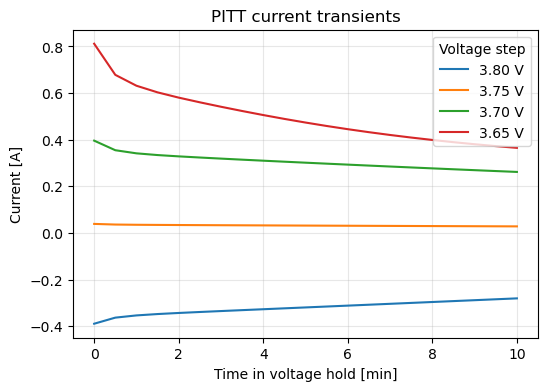

In [5]:
plt.figure(figsize=(6, 4))

for voltage, cycle in zip(voltage_steps, pitt_solution.cycles):
    hold = cycle.steps[0]
    t = hold["Time [s]"].entries - hold["Time [s]"].entries[0]
    i = hold["Current [A]"].entries
    plt.plot(t / 60, i, label=f"{voltage:.2f} V")

plt.xlabel("Time in voltage hold [min]")
plt.ylabel("Current [A]")
plt.title("PITT current transients")
plt.grid(True, alpha=0.3)
plt.legend(title="Voltage step")
plt.show()

## Teaching prompts

- Increase the rest time and watch the relaxed GITT voltage change.
- Change the GITT pulse rate from C/20 to C/10.
- Use smaller PITT voltage steps to reduce the transient current.